In [2]:
import tensorflow as tf
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/BenglaDataset14k.csv")
df['label'] = df['label'].astype(int)  # Ensure integer labels

# Split train/test
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['text'].tolist(), df['label'].tolist(), test_size=0.2, random_state=42
)

# Load tokenizer and model (convert PyTorch weights)
model_name = "csebuetnlp/banglabert"
tokenizer = AutoTokenizer.from_pretrained(model_name)
num_labels = len(set(df['label']))

model = TFAutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=num_labels,
    from_pt=True  # Important: convert PyTorch weights
)

# Tokenize
def tokenize_texts(texts):
    return tokenizer(texts, padding=True, truncation=True, max_length=128, return_tensors="tf")

train_encodings = tokenize_texts(train_texts)
test_encodings = tokenize_texts(test_texts)

# Convert labels to tensors
train_labels_tf = tf.convert_to_tensor(train_labels)
test_labels_tf = tf.convert_to_tensor(test_labels)

# Create TF datasets
train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_encodings), train_labels_tf)).shuffle(1000).batch(16)
test_dataset = tf.data.Dataset.from_tensor_slices((dict(test_encodings), test_labels_tf)).batch(16)

# Compile model
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-5)
loss = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
metrics = ['accuracy']

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Ready to train:
# model.fit(train_dataset, validation_data=test_dataset, epochs=3)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/119 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/586 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/443M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFElectraForSequenceClassification: ['electra.embeddings.position_ids', 'discriminator_predictions.dense_prediction.bias', 'discriminator_predictions.dense.bias', 'discriminator_predictions.dense_prediction.weight', 'discriminator_predictions.dense.weight']
- This IS expected if you are initializing TFElectraForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFElectraForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
So

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

# Train the model
history=model.fit(train_dataset, validation_data=test_dataset, epochs=6)



Epoch 1/6
698/698 [==============================] - 380s 464ms/step - loss: 0.0836 - accuracy: 0.9701 - val_loss: 0.0182 - val_accuracy: 0.9936
Epoch 2/6
698/698 [==============================] - 315s 451ms/step - loss: 0.0073 - accuracy: 0.9970 - val_loss: 0.0159 - val_accuracy: 0.9961
Epoch 3/6
698/698 [==============================] - 314s 450ms/step - loss: 0.0047 - accuracy: 0.9985 - val_loss: 0.0259 - val_accuracy: 0.9953
Epoch 4/6
698/698 [==============================] - 314s 450ms/step - loss: 0.0018 - accuracy: 0.9994 - val_loss: 0.0164 - val_accuracy: 0.9925
Epoch 5/6
698/698 [==============================] - 313s 449ms/step - loss: 0.0039 - accuracy: 0.9986 - val_loss: 0.0265 - val_accuracy: 0.9936
Epoch 6/6
698/698 [==============================] - 314s 449ms/step - loss: 0.0034 - accuracy: 0.9990 - val_loss: 0.0269 - val_accuracy: 0.9953


In [4]:
# Test predictions
sample_texts = ["এই খবরটি পুরোপুরি মিথ্যা এবং বিভ্রান্তিকর"]
sample_encodings = tokenize_texts(sample_texts)
predictions = model(sample_encodings)
predicted_labels = tf.argmax(predictions.logits, axis=-1)
print("Predicted labels:", predicted_labels.numpy())


Predicted labels: [0]


In [ ]:
print(df['label'].value_counts())


label
0    7000
1    6951
Name: count, dtype: int64


In [5]:
import tensorflow as tf

# Get predictions
predictions = model.predict(test_dataset)
predicted_labels = tf.argmax(predictions.logits, axis=-1)

# Get true labels
true_labels = []
for _, labels in test_dataset:
    true_labels.extend(labels.numpy())

# Convert to tensor and ensure it's int32
true_labels = tf.convert_to_tensor(true_labels, dtype=tf.int32)

# Ensure predicted_labels is also int32 before comparison
predicted_labels = tf.cast(predicted_labels, dtype=tf.int32)

# Calculate correct predictions
correct = tf.reduce_sum(tf.cast(predicted_labels == true_labels, tf.int32))
total = len(true_labels)
accuracy = correct / total

print(f"Test Accuracy: {accuracy.numpy()*100:.2f}%")

175/175 [==============================] - 28s 142ms/step
Test Accuracy: 99.53%


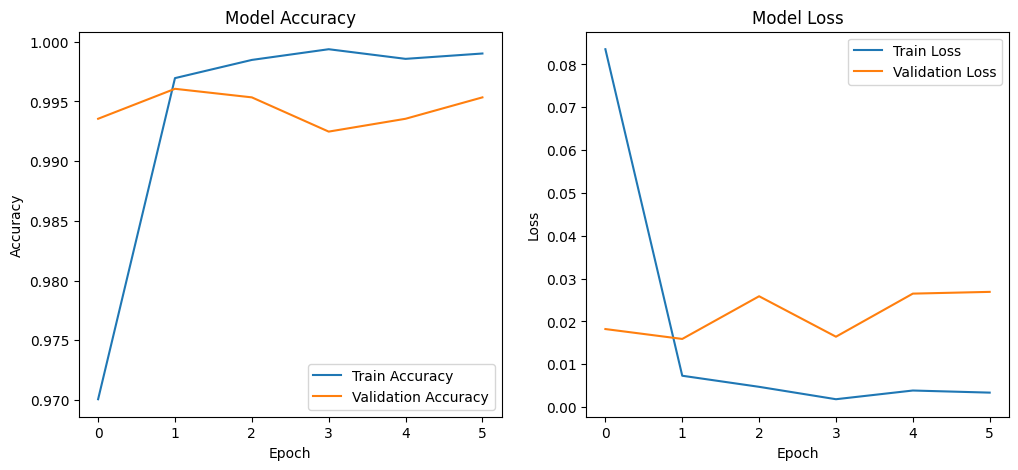

In [6]:
import matplotlib.pyplot as plt


# Plot training & validation accuracy
plt.figure(figsize=(12, 5))

# Accuracy plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()


175/175 [==============================] - 25s 144ms/step

BanglaBERT ROC-AUC Score: 0.9999


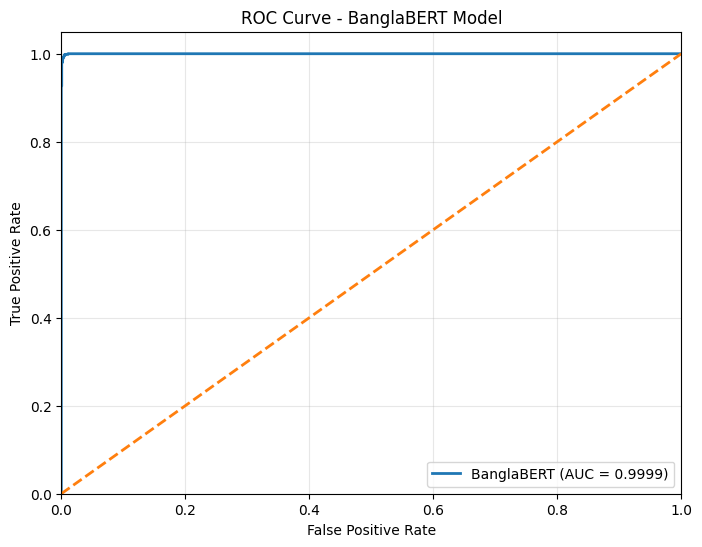

✓ ROC curve saved as 'banglabert_roc_curve.png'


In [7]:
# ===================== ROC CURVE & AUC =====================
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Get model prediction logits on test set
pred_logits = model.predict(test_dataset).logits

# Convert logits to probabilities
pred_probs = tf.nn.softmax(pred_logits, axis=1).numpy()

# True labels
y_true = np.array(test_labels)

# Probability of positive class (class = 1)
y_score = pred_probs[:, 1]

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

print(f"\nBanglaBERT ROC-AUC Score: {roc_auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, lw=2, label=f'BanglaBERT (AUC = {roc_auc:.4f})')
plt.plot([0,1], [0,1], linestyle='--', lw=2)  # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - BanglaBERT Model")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.savefig("banglabert_roc_curve.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ ROC curve saved as 'banglabert_roc_curve.png'")


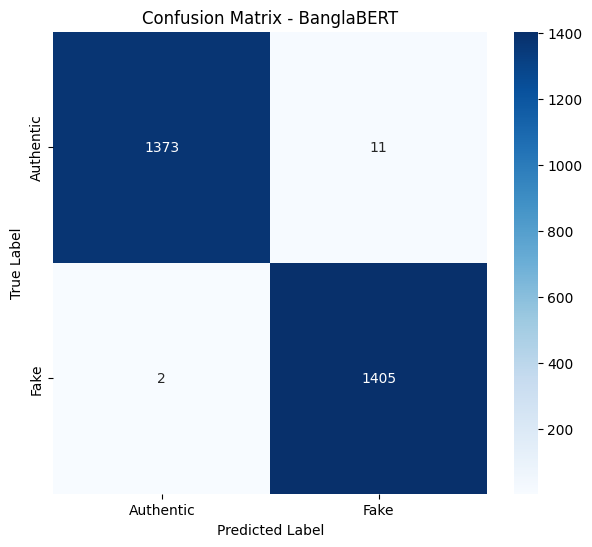

✓ Confusion matrix saved as 'banglabert_confusion_matrix.png'

Classification Report:

              precision    recall  f1-score   support

   Authentic       1.00      0.99      1.00      1384
        Fake       0.99      1.00      1.00      1407

    accuracy                           1.00      2791
   macro avg       1.00      1.00      1.00      2791
weighted avg       1.00      1.00      1.00      2791



In [8]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Get predicted class labels
y_pred_classes = np.argmax(pred_probs, axis=1)

# True labels
y_true = np.array(test_labels)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Plot confusion matrix
plt.figure(figsize=(7,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Authentic', 'Fake'],
            yticklabels=['Authentic', 'Fake'])

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - BanglaBERT")
plt.savefig("banglabert_confusion_matrix.png", dpi=300, bbox_inches='tight')
plt.show()

print("✓ Confusion matrix saved as 'banglabert_confusion_matrix.png'")

# Optional: Classification Report
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes, target_names=['Authentic','Fake']))
